<a href="https://colab.research.google.com/github/sumantabhargab/SAFE5G/blob/main/notebook1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle tqdm split-folders opencv-python

In [2]:
import os

os.environ["KAGGLE_USERNAME"] = "yukohitaro"

os.environ["KAGGLE_KEY"] = "KGAT_751e60ded89b28c0b4428a2689e4bfc6"

In [3]:
!kaggle datasets download \
-d mohamedmustafa/real-life-violence-situations-dataset

Dataset URL: https://www.kaggle.com/datasets/mohamedmustafa/real-life-violence-situations-dataset
License(s): copyright-authors
100% 3.58G/3.58G [03:40<00:00, 17.5MB/s]



In [4]:
!unzip -q real-life-violence-situations-dataset.zip

In [5]:
import os

for root, dirs, files in os.walk("/content/Real Life Violence Dataset"):

    if len(files):

        print(root)

        print(files[:5])

        print()

/content/Real Life Violence Dataset/Violence
['V_257.mp4', 'V_294.mp4', 'V_931.mp4', 'V_906.mp4', 'V_699.mp4']

/content/Real Life Violence Dataset/NonViolence
['NV_781.mp4', 'NV_231.mp4', 'NV_381.mp4', 'NV_499.mp4', 'NV_717.mp4']



In [6]:
import os

violence = len(os.listdir("/content/Real Life Violence Dataset/Violence"))

normal = len(os.listdir("/content/Real Life Violence Dataset/NonViolence"))

print("Violence Videos :", violence)

print("NonViolence Videos :", normal)

Violence Videos : 1000
NonViolence Videos : 1000


In [7]:
import os

print(os.path.exists("/content/Real Life Violence Dataset"))

True


In [8]:
import os
import random
import shutil

random.seed(42)

ROOT = "/content/Real Life Violence Dataset"
OUTPUT = "/content/Safe5G_Dataset"

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

classes = ["Violence", "NonViolence"]

# --------------------------------------------------
# Create Folder Structure
# --------------------------------------------------

for split in ["train", "val", "test"]:

    for cls in classes:

        os.makedirs(
            os.path.join(OUTPUT, split, cls),
            exist_ok=True
        )

# --------------------------------------------------
# Split Videos
# --------------------------------------------------

for cls in classes:

    source_folder = os.path.join(ROOT, cls)

    videos = [
        v for v in os.listdir(source_folder)
        if v.lower().endswith((".mp4", ".avi", ".mov"))
    ]

    random.shuffle(videos)

    total = len(videos)

    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_videos = videos[:train_end]
    val_videos = videos[train_end:val_end]
    test_videos = videos[val_end:]

    splits = {
        "train": train_videos,
        "val": val_videos,
        "test": test_videos
    }

    for split_name, split_list in splits.items():

        destination = os.path.join(
            OUTPUT,
            split_name,
            cls
        )

        for video in split_list:

            shutil.copy2(

                os.path.join(source_folder, video),

                os.path.join(destination, video)

            )

    print(f"{cls}")
    print(f"Train : {len(train_videos)}")
    print(f"Val   : {len(val_videos)}")
    print(f"Test  : {len(test_videos)}")
    print("-" * 40)

print("\nDataset Split Completed Successfully.")

Violence
Train : 800
Val   : 100
Test  : 100
----------------------------------------
NonViolence
Train : 800
Val   : 100
Test  : 100
----------------------------------------

Dataset Split Completed Successfully.


In [9]:
import os

ROOT = "/content/Safe5G_Dataset"

for split in ["train", "val", "test"]:

    print(f"\n===== {split.upper()} =====")

    for cls in ["Violence", "NonViolence"]:

        folder = os.path.join(ROOT, split, cls)

        print(
            cls,
            len(os.listdir(folder))
        )


===== TRAIN =====
Violence 800
NonViolence 800

===== VAL =====
Violence 100
NonViolence 100

===== TEST =====
Violence 100
NonViolence 100


In [10]:
import os
import cv2
import json

DATASET = "/content/Safe5G_Dataset"
OUTPUT = "/content/Safe5G_Frames"

FRAME_SKIP = 10
SHARPNESS_THRESHOLD = 120

IMG_SIZE = (224,224)

metadata = {}

for split in ["train","val","test"]:

    metadata[split] = {}

    for cls in ["Violence","NonViolence"]:

        metadata[split][cls] = {}

        source = os.path.join(DATASET,split,cls)

        destination = os.path.join(OUTPUT,split,cls)

        os.makedirs(destination,exist_ok=True)

        videos = sorted(os.listdir(source))

        print(f"\nExtracting {split}/{cls}")

        for video in videos:

            video_path = os.path.join(source,video)

            cap = cv2.VideoCapture(video_path)

            frame_id = 0
            saved = 0

            while True:

                ret,frame = cap.read()

                if not ret:
                    break

                if frame_id % FRAME_SKIP == 0:

                    gray = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)

                    sharpness = cv2.Laplacian(
                        gray,
                        cv2.CV_64F
                    ).var()

                    if sharpness > SHARPNESS_THRESHOLD:

                        frame = cv2.resize(
                            frame,
                            IMG_SIZE
                        )

                        filename = f"{video[:-4]}_{saved}.jpg"

                        cv2.imwrite(

                            os.path.join(
                                destination,
                                filename
                            ),

                            frame

                        )

                        saved += 1

                frame_id += 1

            cap.release()

            metadata[split][cls][video] = saved

with open("/content/frame_metadata.json","w") as f:

    json.dump(metadata,f,indent=4)

print("\nFinished.")


Extracting train/Violence

Extracting train/NonViolence

Extracting val/Violence

Extracting val/NonViolence

Extracting test/Violence

Extracting test/NonViolence

Finished.


In [11]:
import os

ROOT="/content/Safe5G_Frames"

for split in ["train","val","test"]:

    print("\n",split.upper())

    for cls in ["Violence","NonViolence"]:

        folder=os.path.join(ROOT,split,cls)

        print(cls,len(os.listdir(folder)))


 TRAIN
Violence 7255
NonViolence 9827

 VAL
Violence 774
NonViolence 1142

 TEST
Violence 719
NonViolence 1148


In [12]:
import os

ROOT = "/content/Safe5G_Frames"

total = 0

for split in ["train", "val", "test"]:

    print("\n" + "="*40)
    print(split.upper())
    print("="*40)

    for cls in ["Violence", "NonViolence"]:

        folder = os.path.join(ROOT, split, cls)

        count = len(os.listdir(folder))

        total += count

        print(f"{cls:<15}: {count}")

print("\nTotal Images:", total)


TRAIN
Violence       : 7255
NonViolence    : 9827

VAL
Violence       : 774
NonViolence    : 1142

TEST
Violence       : 719
NonViolence    : 1148

Total Images: 20865


In [13]:
import json

with open("/content/frame_metadata.json") as f:

    metadata = json.load(f)

metadata.keys()

dict_keys(['train', 'val', 'test'])

In [14]:
train_violence = metadata["train"]["Violence"]

frame_counts = list(train_violence.values())

print("Maximum:", max(frame_counts))
print("Minimum:", min(frame_counts))
print("Average:", sum(frame_counts)/len(frame_counts))

Maximum: 355
Minimum: 0
Average: 9.06875


In [15]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMAGE_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

ROOT="/content/Safe5G_Frames"

train_dataset = datasets.ImageFolder(
    ROOT+"/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    ROOT+"/val",
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    ROOT+"/test",
    transform=test_transform
)

print("Class Mapping:", train_dataset.class_to_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print()

print("Training Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("Testing Images :", len(test_dataset))

Class Mapping: {'NonViolence': 0, 'Violence': 1}

Training Images : 17082
Validation Images : 1916
Testing Images : 1867


In [16]:
import os
import json

ROOT = "/content/Safe5G_Frames"

stats = {}

total_images = 0

for split in ["train","val","test"]:

    stats[split] = {}

    split_total = 0

    for cls in ["Violence","NonViolence"]:

        folder = os.path.join(ROOT,split,cls)

        count = len(os.listdir(folder))

        stats[split][cls] = count

        split_total += count

    stats[split]["total"] = split_total

    total_images += split_total

stats["overall_total"] = total_images

print(json.dumps(stats,indent=4))

{
    "train": {
        "Violence": 7255,
        "NonViolence": 9827,
        "total": 17082
    },
    "val": {
        "Violence": 774,
        "NonViolence": 1142,
        "total": 1916
    },
    "test": {
        "Violence": 719,
        "NonViolence": 1148,
        "total": 1867
    },
    "overall_total": 20865
}


In [17]:
with open("/content/dataset_statistics.json","w") as f:

    json.dump(stats,f,indent=4)

print("Dataset statistics saved.")

Dataset statistics saved.


In [17]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [19]:
FRAME_DIR = "/content/Safe5G_Frames"

TRAIN_DIR = os.path.join(FRAME_DIR, "train")
VAL_DIR = os.path.join(FRAME_DIR, "val")
TEST_DIR = os.path.join(FRAME_DIR, "test")

MODEL_DIR = "/content/Models"
RESULT_DIR = "/content/Results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

In [20]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [21]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

print("Classes:", train_dataset.classes)

Classes: ['NonViolence', 'Violence']


In [22]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 17082
Validation: 1916
Test: 1867


In [26]:
# ============================
# Standard Libraries
# ============================

import os
import cv2
import json
import shutil
import random
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ============================
# PyTorch
# ============================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ============================
# EfficientNet
# ============================

import timm

# ============================
# Scikit-Learn
# ============================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================
# Miscellaneous
# ============================

from PIL import Image

# ============================
# Random Seed
# ============================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*50)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("="*50)

Device: cuda
GPU: Tesla T4


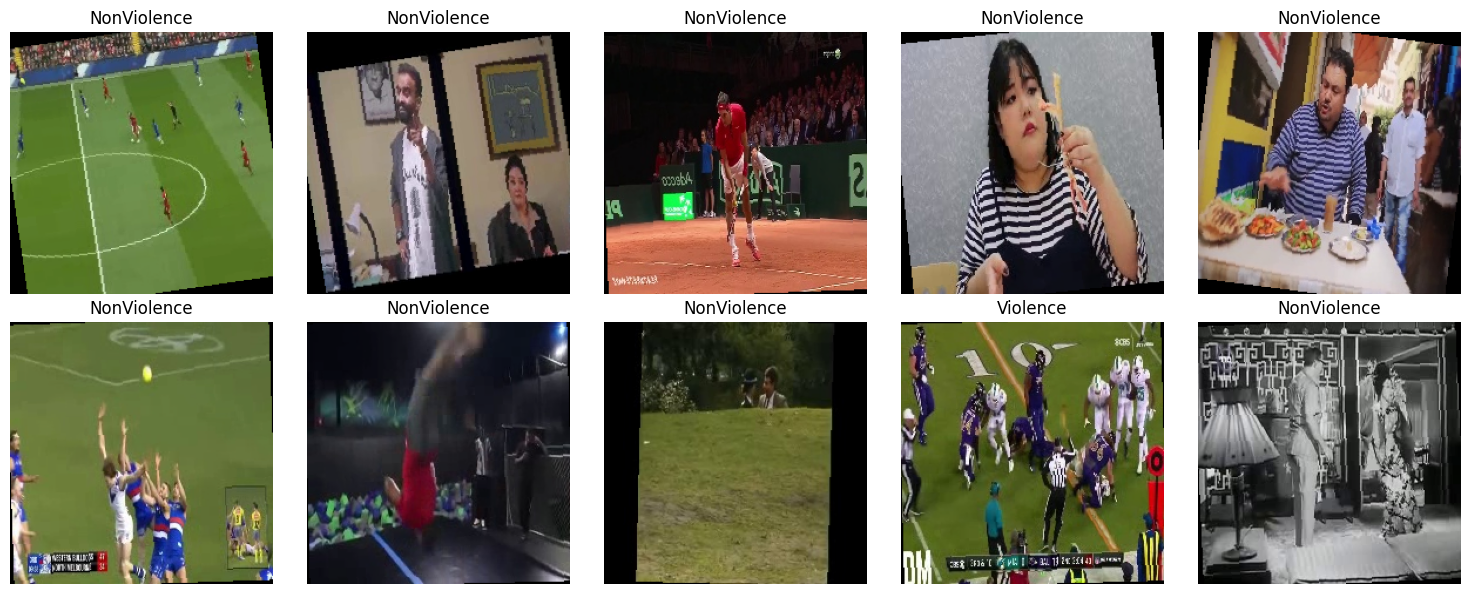

In [27]:
fig, axes = plt.subplots(2,5, figsize=(15,6))

for ax in axes.flatten():

    image, label = random.choice(train_dataset)

    image = image.permute(1,2,0).numpy()

    image = image * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    image = np.clip(image,0,1)

    ax.imshow(image)
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [28]:
# Model Configuration
MODEL_NAME = "efficientnet_b0"
NUM_CLASSES = len(train_dataset.classes)

model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

print(model)

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [29]:
LEARNING_RATE = 1e-4
EPOCHS = 10

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

print("Loss and Optimizer Ready!")

Loss and Optimizer Ready!


In [30]:
from torch.cuda.amp import GradScaler, autocast

scaler = GradScaler()

print("Mixed Precision Enabled")

Mixed Precision Enabled


In [31]:
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [32]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    return loss, accuracy

In [33]:
# Lists to store history

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_acc = 0

print("=" * 60)
print("Training Started")
print("=" * 60)

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_acc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            os.path.join(MODEL_DIR, "violence_classifier.pth")
        )

        print("✅ Best model saved!")

print("\nTraining Finished!")
print("Best Validation Accuracy:", best_acc)

Training Started
Epoch [1/10] | Train Loss: 0.2667 | Train Acc: 93.33% | Val Loss: 0.1977 | Val Acc: 96.19%
✅ Best model saved!
Epoch [2/10] | Train Loss: 0.0551 | Train Acc: 98.28% | Val Loss: 0.0994 | Val Acc: 98.23%
✅ Best model saved!
Epoch [3/10] | Train Loss: 0.0307 | Train Acc: 98.99% | Val Loss: 0.1066 | Val Acc: 97.44%
Epoch [4/10] | Train Loss: 0.0203 | Train Acc: 99.33% | Val Loss: 0.0895 | Val Acc: 98.07%
Epoch [5/10] | Train Loss: 0.0168 | Train Acc: 99.41% | Val Loss: 0.0949 | Val Acc: 97.81%
Epoch [6/10] | Train Loss: 0.0096 | Train Acc: 99.69% | Val Loss: 0.0737 | Val Acc: 98.17%
Epoch [7/10] | Train Loss: 0.0067 | Train Acc: 99.77% | Val Loss: 0.0833 | Val Acc: 98.23%
Epoch [8/10] | Train Loss: 0.0058 | Train Acc: 99.78% | Val Loss: 0.0760 | Val Acc: 98.38%
✅ Best model saved!
Epoch [9/10] | Train Loss: 0.0074 | Train Acc: 99.71% | Val Loss: 0.0601 | Val Acc: 98.49%
✅ Best model saved!
Epoch [10/10] | Train Loss: 0.0067 | Train Acc: 99.75% | Val Loss: 0.0842 | Val Acc:

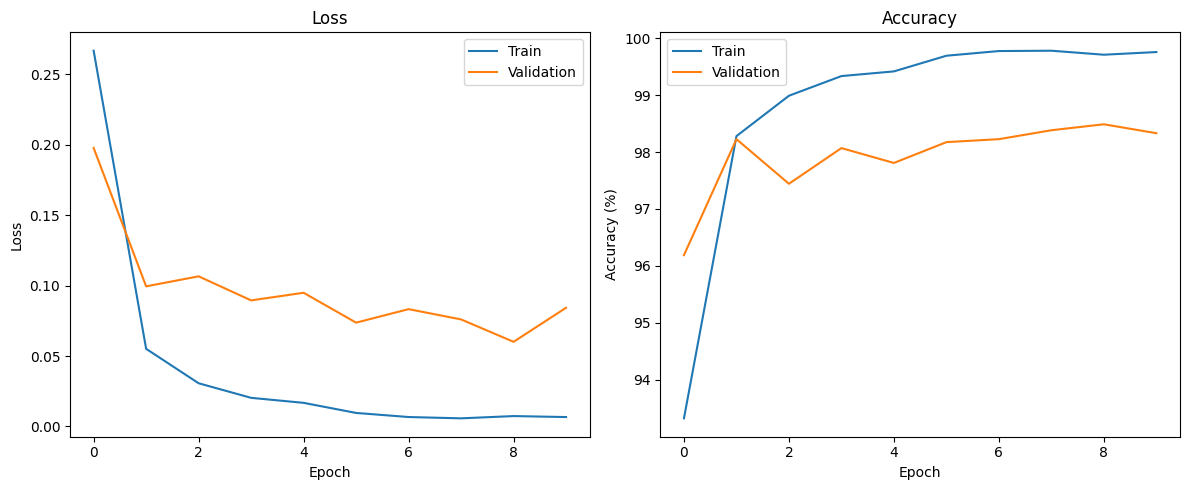

In [34]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
model.load_state_dict(
    torch.load(
        os.path.join(MODEL_DIR, "violence_classifier.pth")
    )
)

model.eval()

print("Best model loaded.")

Best model loaded.


In [36]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("="*50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("="*50)

Accuracy : 0.9636
Precision: 0.9477
Recall   : 0.9583
F1 Score : 0.9530


In [37]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

 NonViolence       0.97      0.97      0.97      1148
    Violence       0.95      0.96      0.95       719

    accuracy                           0.96      1867
   macro avg       0.96      0.96      0.96      1867
weighted avg       0.96      0.96      0.96      1867



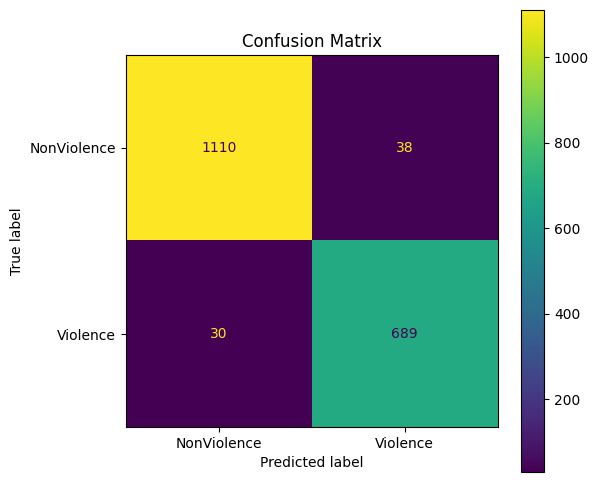

In [38]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax)

plt.title("Confusion Matrix")
plt.show()

In [39]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),
    transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(3, sigma=(0.1,2.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])